# Sinan vs Sinan+ (4D CNN) Comparison
**Transformer-Driven Microservice Autoscaling — Group 10**

This notebook trains:
1. **Sinan (original)**: CNN with 5 feature channels (N × T × 5)
2. **Sinan+ (4D)**: CNN with 10 doubled feature channels (N × T × 10)

And compares their accuracy on sequential-heavy vs fan-out-heavy workloads.

## 1. Setup & Load Data

In [ ]:
# Mount Google Drive (upload your .npy files there first)
from google.colab import drive
drive.mount('/content/drive')

# Set path to your data
DATA_DIR = '/content/drive/MyDrive/tensors/mixed'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import json
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_auc_score, mean_squared_error, mean_absolute_error
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [ ]:
# Load tensors
X_RH = np.load(os.path.join(DATA_DIR, 'X_RH.npy'))              # (N_samples, 26, 10, 5)
X_RH_doubled = np.load(os.path.join(DATA_DIR, 'X_RH_doubled.npy'))  # (N_samples, 26, 10, 10)
X_LH = np.load(os.path.join(DATA_DIR, 'X_LH.npy'))              # (N_samples, 10, 3)
X_RC = np.load(os.path.join(DATA_DIR, 'X_RC.npy'))              # (N_samples, 26)
Y_latency = np.load(os.path.join(DATA_DIR, 'Y_latency.npy'))    # (N_samples, 3)
Y_violation = np.load(os.path.join(DATA_DIR, 'Y_violation.npy'))  # (N_samples,)

with open(os.path.join(DATA_DIR, 'metadata.json')) as f:
    meta = json.load(f)

print('Loaded data shapes:')
for name, arr in [('X_RH', X_RH), ('X_RH_doubled', X_RH_doubled), ('X_LH', X_LH),
                   ('X_RC', X_RC), ('Y_latency', Y_latency), ('Y_violation', Y_violation)]:
    print(f'  {name}: {arr.shape}')
print(f'  Violation rate: {Y_violation.mean():.2%}')

Loaded data shapes:
  X_RH: (58, 26, 10, 5)
  X_RH_doubled: (58, 26, 10, 10)
  X_LH: (58, 10, 3)
  X_RC: (58, 26)
  Y_latency: (58, 3)
  Y_violation: (58,)
  Violation rate: 0.00%


## 2. Dataset & DataLoader

In [ ]:
class SinanDataset(Dataset):
    def __init__(self, X_RH, X_LH, X_RC, Y_latency, Y_violation):
        # Conv2D expects (batch, channels, H, W)
        # Our X_RH is (samples, N_tiers, T, F) → transpose to (samples, F, N_tiers, T)
        self.x_rh = torch.FloatTensor(X_RH.transpose(0, 3, 1, 2))  # (N, F, 26, 10)
        self.x_lh = torch.FloatTensor(X_LH.reshape(X_LH.shape[0], -1))  # (N, T*3) flattened
        self.x_rc = torch.FloatTensor(X_RC)  # (N, 26)
        self.y_lat = torch.FloatTensor(Y_latency)  # (N, 3)
        self.y_viol = torch.FloatTensor(Y_violation)  # (N,)

    def __len__(self):
        return len(self.x_rh)

    def __getitem__(self, idx):
        return self.x_rh[idx], self.x_lh[idx], self.x_rc[idx], self.y_lat[idx], self.y_viol[idx]

## 3. Model Definition

In [ ]:
class SinanCNN(nn.Module):
    """
    PyTorch reimplementation of Sinan's CNN latency predictor.

    The ONLY difference between Sinan and Sinan+ is n_features:
      Sinan:  n_features=5  (cpu, mem_rss, mem_cache, net_rx, net_tx)
      Sinan+: n_features=10 (each feature × {sequential, fanout})
    """
    def __init__(self, n_tiers=26, n_timesteps=10, n_features=5, n_latency_bins=3):
        super().__init__()

        # ---- Resource history branch (Conv2D over tiers × time) ----
        self.conv_block = nn.Sequential(
            nn.Conv2d(n_features, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )
        conv_out_size = 64 * n_tiers * n_timesteps

        # ---- Latency history branch ----
        self.latency_branch = nn.Sequential(
            nn.Linear(n_timesteps * n_latency_bins, 64),
            nn.ReLU(),
        )

        # ---- Resource config branch ----
        self.config_branch = nn.Sequential(
            nn.Linear(n_tiers, 64),
            nn.ReLU(),
        )

        # ---- Combined ----
        self.fc = nn.Sequential(
            nn.Linear(conv_out_size + 64 + 64, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
        )

        # Latency prediction head
        self.latency_head = nn.Linear(128, n_latency_bins)

        # Violation prediction head
        self.violation_head = nn.Linear(128, 1)

    def forward(self, x_rh, x_lh, x_rc):
        # Conv branch
        h = self.conv_block(x_rh)  # (B, 64, 26, 10)
        h = h.flatten(1)            # (B, 64*26*10)

        # Other branches
        l = self.latency_branch(x_lh)
        c = self.config_branch(x_rc)

        # Combine
        combined = torch.cat([h, l, c], dim=1)
        latent = self.fc(combined)  # (B, 128) — this is Lf

        lat_pred = self.latency_head(latent)          # (B, 3)
        viol_pred = self.violation_head(latent).squeeze(-1)  # (B,)

        return lat_pred, viol_pred, latent

## 4. Training Loop

In [ ]:
def train_model(model, train_loader, val_loader, epochs=50, lr=1e-3, model_name='model'):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    lat_criterion = nn.MSELoss()
    viol_criterion = nn.BCEWithLogitsLoss()

    history = {'train_loss': [], 'val_loss': [], 'val_lat_rmse': [], 'val_viol_f1': []}

    for epoch in range(epochs):
        # ---- Train ----
        model.train()
        train_loss = 0
        for x_rh, x_lh, x_rc, y_lat, y_viol in train_loader:
            x_rh, x_lh, x_rc = x_rh.to(device), x_lh.to(device), x_rc.to(device)
            y_lat, y_viol = y_lat.to(device), y_viol.to(device)

            lat_pred, viol_pred, _ = model(x_rh, x_lh, x_rc)

            loss_lat = lat_criterion(lat_pred, y_lat)
            loss_viol = viol_criterion(viol_pred, y_viol)
            loss = loss_lat + 0.5 * loss_viol  # weighted combination

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)

        # ---- Validate ----
        model.eval()
        val_loss = 0
        all_lat_pred, all_lat_true = [], []
        all_viol_pred, all_viol_true = [], []

        with torch.no_grad():
            for x_rh, x_lh, x_rc, y_lat, y_viol in val_loader:
                x_rh, x_lh, x_rc = x_rh.to(device), x_lh.to(device), x_rc.to(device)
                y_lat, y_viol = y_lat.to(device), y_viol.to(device)

                lat_pred, viol_pred, _ = model(x_rh, x_lh, x_rc)

                loss_lat = lat_criterion(lat_pred, y_lat)
                loss_viol = viol_criterion(viol_pred, y_viol)
                val_loss += (loss_lat + 0.5 * loss_viol).item()

                all_lat_pred.append(lat_pred.cpu().numpy())
                all_lat_true.append(y_lat.cpu().numpy())
                all_viol_pred.append(torch.sigmoid(viol_pred).cpu().numpy())
                all_viol_true.append(y_viol.cpu().numpy())

        val_loss /= len(val_loader)
        scheduler.step(val_loss)

        all_lat_pred = np.concatenate(all_lat_pred)
        all_lat_true = np.concatenate(all_lat_true)
        all_viol_pred = np.concatenate(all_viol_pred)
        all_viol_true = np.concatenate(all_viol_true)

        # p99 RMSE (column index 2)
        rmse_p99 = np.sqrt(mean_squared_error(all_lat_true[:, 2], all_lat_pred[:, 2]))
        mae_p99 = mean_absolute_error(all_lat_true[:, 2], all_lat_pred[:, 2])

        # Violation F1
        viol_binary = (all_viol_pred > 0.5).astype(int)
        f1 = f1_score(all_viol_true, viol_binary, zero_division=0)
        try:
            auc = roc_auc_score(all_viol_true, all_viol_pred)
        except ValueError:
            auc = 0.0

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_lat_rmse'].append(rmse_p99)
        history['val_viol_f1'].append(f1)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'[{model_name}] Epoch {epoch+1:3d} | '
                  f'Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | '
                  f'p99 RMSE: {rmse_p99:.2f}ms MAE: {mae_p99:.2f}ms | '
                  f'Viol F1: {f1:.3f} AUC: {auc:.3f}')

    return model, history

## 5. Train Both Models

In [ ]:
BATCH_SIZE = 64
EPOCHS = 50
LR = 1e-3
VAL_SPLIT = 0.2

# ---- Sinan (original, 5 channels) ----
print('='*60)
print('Training Sinan (original, 5 channels)')
print('='*60)

ds_orig = SinanDataset(X_RH, X_LH, X_RC, Y_latency, Y_violation)
n_val = int(len(ds_orig) * VAL_SPLIT)
n_train = len(ds_orig) - n_val
train_ds, val_ds = random_split(ds_orig, [n_train, n_val],
                                generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

model_orig = SinanCNN(n_features=5)  # ← 5 channels
model_orig, hist_orig = train_model(model_orig, train_loader, val_loader,
                                     epochs=EPOCHS, lr=LR, model_name='Sinan')

print()

# ---- Sinan+ (doubled, 10 channels) ----
print('='*60)
print('Training Sinan+ (doubled channels, 10 features)')
print('='*60)

ds_plus = SinanDataset(X_RH_doubled, X_LH, X_RC, Y_latency, Y_violation)
train_ds_p, val_ds_p = random_split(ds_plus, [n_train, n_val],
                                     generator=torch.Generator().manual_seed(42))

train_loader_p = DataLoader(train_ds_p, batch_size=BATCH_SIZE, shuffle=True)
val_loader_p = DataLoader(val_ds_p, batch_size=BATCH_SIZE)

model_plus = SinanCNN(n_features=10)  # ← 10 channels (THE ONLY CHANGE)
model_plus, hist_plus = train_model(model_plus, train_loader_p, val_loader_p,
                                     epochs=EPOCHS, lr=LR, model_name='Sinan+')

Training Sinan (original, 5 channels)
[Sinan] Epoch   1 | Train Loss: 741.1639 | Val Loss: 611.7160 | p99 RMSE: 37.43ms MAE: 37.35ms | Viol F1: 0.000 AUC: nan
[Sinan] Epoch   5 | Train Loss: 18.5231 | Val Loss: 289.2806 | p99 RMSE: 25.58ms MAE: 25.49ms | Viol F1: 0.000 AUC: nan
[Sinan] Epoch  10 | Train Loss: 47.9343 | Val Loss: 280.8157 | p99 RMSE: 25.12ms MAE: 25.03ms | Viol F1: 0.000 AUC: nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist

[Sinan] Epoch  15 | Train Loss: 19.2073 | Val Loss: 52.4173 | p99 RMSE: 10.92ms MAE: 10.75ms | Viol F1: 0.000 AUC: nan
[Sinan] Epoch  20 | Train Loss: 14.1548 | Val Loss: 27.9440 | p99 RMSE: 8.17ms MAE: 7.94ms | Viol F1: 0.000 AUC: nan
[Sinan] Epoch  25 | Train Loss: 16.7491 | Val Loss: 3.6412 | p99 RMSE: 1.93ms MAE: 1.62ms | Viol F1: 0.000 AUC: nan
[Sinan] Epoch  30 | Train Loss: 8.3928 | Val Loss: 4.5341 | p99 RMSE: 2.62ms MAE: 2.23ms | Viol F1: 0.000 AUC: nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist

[Sinan] Epoch  35 | Train Loss: 9.3462 | Val Loss: 4.6806 | p99 RMSE: 2.15ms MAE: 1.68ms | Viol F1: 0.000 AUC: nan
[Sinan] Epoch  40 | Train Loss: 9.9735 | Val Loss: 3.5924 | p99 RMSE: 2.02ms MAE: 1.65ms | Viol F1: 0.000 AUC: nan
[Sinan] Epoch  45 | Train Loss: 7.5312 | Val Loss: 3.4201 | p99 RMSE: 1.96ms MAE: 1.79ms | Viol F1: 0.000 AUC: nan
[Sinan] Epoch  50 | Train Loss: 9.8433 | Val Loss: 3.4560 | p99 RMSE: 2.00ms MAE: 1.82ms | Viol F1: 0.000 AUC: nan

Training Sinan+ (doubled channels, 10 features)


...

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist

[Sinan+] Epoch  30 | Train Loss: 10.4077 | Val Loss: 3.5819 | p99 RMSE: 2.04ms MAE: 1.86ms | Viol F1: 0.000 AUC: nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist

[Sinan+] Epoch  35 | Train Loss: 8.9484 | Val Loss: 4.8157 | p99 RMSE: 2.71ms MAE: 2.08ms | Viol F1: 0.000 AUC: nan
[Sinan+] Epoch  40 | Train Loss: 8.7202 | Val Loss: 3.2008 | p99 RMSE: 2.00ms MAE: 1.81ms | Viol F1: 0.000 AUC: nan
[Sinan+] Epoch  45 | Train Loss: 7.9977 | Val Loss: 3.2029 | p99 RMSE: 2.02ms MAE: 1.82ms | Viol F1: 0.000 AUC: nan
[Sinan+] Epoch  50 | Train Loss: 8.1194 | Val Loss: 3.2284 | p99 RMSE: 1.95ms MAE: 1.74ms | Viol F1: 0.000 AUC: nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist

## 6. Compare Results

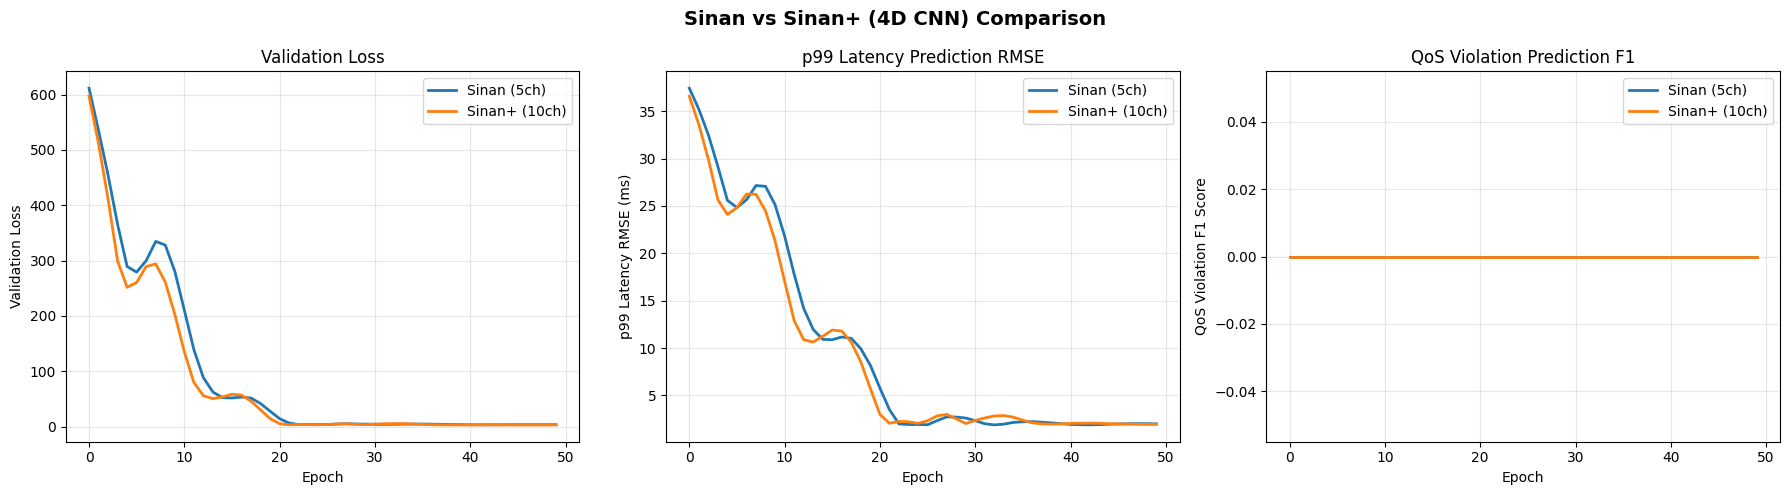


FINAL RESULTS (last epoch)
Metric                        Sinan (5ch)   Sinan+ (10ch)
------------------------------------------------------------
Val Loss                           3.4560          3.2284
p99 RMSE (ms)                        2.00            1.95
Violation F1                        0.000           0.000


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(hist_orig['val_loss'], label='Sinan (5ch)', linewidth=2)
axes[0].plot(hist_plus['val_loss'], label='Sinan+ (10ch)', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Loss')
axes[0].set_title('Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# p99 RMSE
axes[1].plot(hist_orig['val_lat_rmse'], label='Sinan (5ch)', linewidth=2)
axes[1].plot(hist_plus['val_lat_rmse'], label='Sinan+ (10ch)', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('p99 Latency RMSE (ms)')
axes[1].set_title('p99 Latency Prediction RMSE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Violation F1
axes[2].plot(hist_orig['val_viol_f1'], label='Sinan (5ch)', linewidth=2)
axes[2].plot(hist_plus['val_viol_f1'], label='Sinan+ (10ch)', linewidth=2)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('QoS Violation F1 Score')
axes[2].set_title('QoS Violation Prediction F1')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Sinan vs Sinan+ (4D CNN) Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sinan_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print('\n' + '='*60)
print('FINAL RESULTS (last epoch)')
print('='*60)
print(f'{"Metric":<25} {"Sinan (5ch)":>15} {"Sinan+ (10ch)":>15}')
print('-'*60)
print(f'{"Val Loss":<25} {hist_orig["val_loss"][-1]:>15.4f} {hist_plus["val_loss"][-1]:>15.4f}')
print(f'{"p99 RMSE (ms)":<25} {hist_orig["val_lat_rmse"][-1]:>15.2f} {hist_plus["val_lat_rmse"][-1]:>15.2f}')
print(f'{"Violation F1":<25} {hist_orig["val_viol_f1"][-1]:>15.3f} {hist_plus["val_viol_f1"][-1]:>15.3f}')

## 7. Evaluate on Separate Workload Types

If you collected separate datasets for sequential-heavy and fan-out-heavy workloads,
load them here and evaluate both models on each.

In [ ]:
def evaluate_on_dataset(model, X_RH_eval, X_LH_eval, X_RC_eval, Y_lat_eval, Y_viol_eval, name=''):
    """Evaluate a trained model on a specific dataset."""
    ds = SinanDataset(X_RH_eval, X_LH_eval, X_RC_eval, Y_lat_eval, Y_viol_eval)
    loader = DataLoader(ds, batch_size=64)

    model.eval()
    all_lat_pred, all_lat_true = [], []
    all_viol_pred, all_viol_true = [], []

    with torch.no_grad():
        for x_rh, x_lh, x_rc, y_lat, y_viol in loader:
            x_rh, x_lh, x_rc = x_rh.to(device), x_lh.to(device), x_rc.to(device)
            lat_pred, viol_pred, _ = model(x_rh, x_lh, x_rc)
            all_lat_pred.append(lat_pred.cpu().numpy())
            all_lat_true.append(y_lat.numpy())
            all_viol_pred.append(torch.sigmoid(viol_pred).cpu().numpy())
            all_viol_true.append(y_viol.numpy())

    all_lat_pred = np.concatenate(all_lat_pred)
    all_lat_true = np.concatenate(all_lat_true)
    all_viol_pred = np.concatenate(all_viol_pred)
    all_viol_true = np.concatenate(all_viol_true)

    rmse = np.sqrt(mean_squared_error(all_lat_true[:, 2], all_lat_pred[:, 2]))
    mae = mean_absolute_error(all_lat_true[:, 2], all_lat_pred[:, 2])
    f1 = f1_score(all_viol_true, (all_viol_pred > 0.5).astype(int), zero_division=0)
    try:
        auc = roc_auc_score(all_viol_true, all_viol_pred)
    except ValueError:
        auc = 0.0

    print(f'  {name:<20} RMSE: {rmse:.2f}ms  MAE: {mae:.2f}ms  F1: {f1:.3f}  AUC: {auc:.3f}')
    return {'rmse': rmse, 'mae': mae, 'f1': f1, 'auc': auc}


# ---- Load workload-specific test sets (if available) ----
# Uncomment and update paths when you have separate workload data

SEQ_DIR = '/content/drive/MyDrive/tensors/sequential'
FAN_DIR = '/content/drive/MyDrive/tensors/fanout'
#
for eval_dir, label in [(SEQ_DIR, 'Sequential'), (FAN_DIR, 'Fan-out')]:
     X_RH_e = np.load(f'{eval_dir}/X_RH.npy')
     X_RH_d_e = np.load(f'{eval_dir}/X_RH_doubled.npy')
     X_LH_e = np.load(f'{eval_dir}/X_LH.npy')
     X_RC_e = np.load(f'{eval_dir}/X_RC.npy')
     Y_lat_e = np.load(f'{eval_dir}/Y_latency.npy')
     Y_viol_e = np.load(f'{eval_dir}/Y_violation.npy')
#
     print(f'\n{label} workload ({len(X_RH_e)} samples):')
     print('  Sinan (original):')
     evaluate_on_dataset(model_orig, X_RH_e, X_LH_e, X_RC_e, Y_lat_e, Y_viol_e, 'Sinan')
     print('  Sinan+ (4D):')
     evaluate_on_dataset(model_plus, X_RH_d_e, X_LH_e, X_RC_e, Y_lat_e, Y_viol_e, 'Sinan+')

print('\n(Uncomment section 7 code once you have separate workload datasets)')


Sequential workload (57 samples):
  Sinan (original):
  Sinan                RMSE: 5.10ms  MAE: 2.25ms  F1: 0.000  AUC: nan
  Sinan+ (4D):
  Sinan+               RMSE: 5.04ms  MAE: 2.15ms  F1: 0.000  AUC: nan

Fan-out workload (56 samples):
  Sinan (original):
  Sinan                RMSE: 11.17ms  MAE: 9.53ms  F1: 0.000  AUC: nan
  Sinan+ (4D):
  Sinan+               RMSE: 10.83ms  MAE: 9.40ms  F1: 0.000  AUC: nan

(Uncomment section 7 code once you have separate workload datasets)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


## 8. Save Models
Save trained models back to Google Drive for later use.

In [ ]:
SAVE_DIR = '/content/drive/MyDrive/sinan_data/models'
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save(model_orig.state_dict(), f'{SAVE_DIR}/sinan_original.pt')
torch.save(model_plus.state_dict(), f'{SAVE_DIR}/sinan_plus.pt')

print(f'Models saved to {SAVE_DIR}/')

Models saved to /content/drive/MyDrive/sinan_data/models/
